## Detailed Usage Instructions


Given here is a brief overview. See the ipython notebooks within the `examples` folder within this repository for more detailed usage examples. 

### `Doc` the Document builder

The `Doc` class from `pydocmaker` is the basic building element for making a report. Here each element will be appended to the end of the document if no `index` or `chapter` is given. Alternatively the chapter to which to append a document part can be specified by `chapter='xxx'`. Furthermore you can also specify the index position (after which part of the document to insert) by adding `index=i` where `i` is `int`. You can use the object like a list.



### Document part schemas

The basic building blocks for a document are called `document parts` and are always either of type `dict` or type `str` (A string will automatically parsed as a text dict element). 

Each document part has a `typ` field which states the type of document part and a `children` field, which can be either `string` or `list`. This way hirachical documents can be build if needed. 

The `document-parts` are:
- `text`: holds text as string (`children`) which will inserted directly as raw text
- `markdown`: holds text as string (`children`) which will be rendered by markdown markup language before parsing into the documents
- `image`: holds all needed information to render an image in a report. The image data is saved as a string in base64 encoded format in the `imageblob` field. A `caption` (str) can be given which will be inserted below the image. The filename is given by the `children` field. The relative width can be given by the `width` field (float). 
- `verbatim`: holds text as string (`children`) which will be inserted as preformatted text into the documents
- `iter`: a meta `document-part` which holds n sub `document-parts` in the `children` field which will be rendered and inserted into the documents in given order. 

An example of the whole schema is given below.

```json
{
  "text":     {"typ": "text", "children": ""},
  "markdown": {"typ": "markdown", "children": ""},
  "image":    {"typ": "image", "children": "", "imageblob": "", "caption": "", "width": 0.8},
  "verbatim": {"typ": "verbatim", "children": ""},
  "iter":     {"typ": "iter", "children": [] }
}
```


### Adding document parts to a doc

Alternatively you can add elements to a document directly using the add and add_kw methods of the document builders:


In [1]:
import pydocmaker as pyd
print(pyd.__version__)

2.5.5



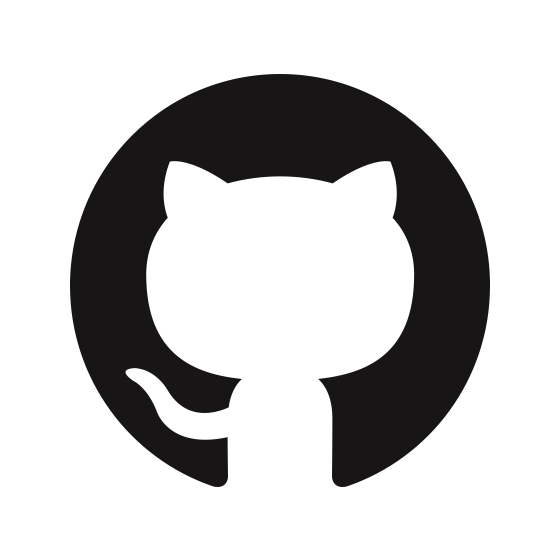

In [2]:

doc = pyd.Doc()
doc.add('dummy text')
doc.add({"typ": "markdown","children": "some dummy markdown text!"})
doc.add_kw('verbatim', 'this text will be shown preformatted!')
doc.add_image('https://github.githubassets.com/assets/GitHub-Mark-ea2971cee799.png', caption='', children='')

doc.show()

### Working with images

Image from pyplot figure



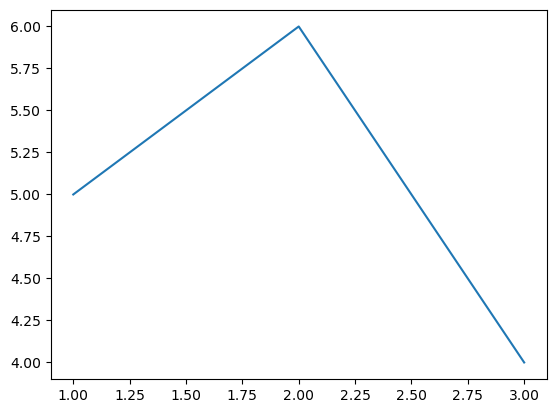

In [3]:
import matplotlib.pyplot as plt

fig = plt.figure()
plt.plot([1, 2, 3], [5, 6, 4])

doc = pyd.Doc()
doc.add(pyd.constr.image_from_fig(caption='test figure', fig=fig))
plt.close()
doc.show()

Image from numpy array 

In [4]:
import numpy as np
m = np.array([np.arange(255).astype(np.uint8).tolist() for i in range(255)], dtype=np.uint8)
doc = pyd.Doc()
doc.add(pyd.constr.image_from_obj(m, caption = 'numpy generated image', width=0.8))

pydocmaker.Doc with N=0 chapters, K=1 elements.


### Adding parts to specific chapters

as said above you can also add elements to specific chapters or locations. below is an example



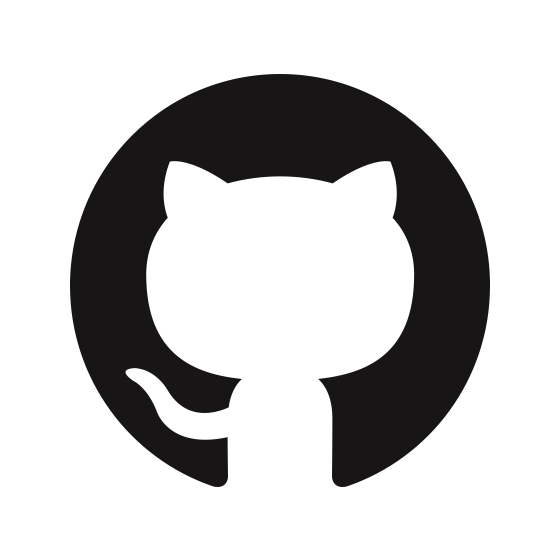

In [5]:
doc = pyd.Doc()

# this will add a section 'Introduction'
doc.add_chapter('Introduction')

# now I can add / access the section (which is a Doc) direcly like a dict
doc.add('dummy text which will be added to the introduction', chapter='Introduction')

# this will add the section 'Weather Info' and add a markdown element to it
doc.add_kw('markdown', 'This is my fancy `markdown` text for the Second Chapter', 
           chapter='Second Chapter')

# I can also add parts to the Introduction like this
doc.add_kw('markdown', 'This text will be appended to the first section after the 2nd element (`index` is zero based!), which is the text (the chapter definition itself is the 1st element!)', 
           index=1)

# and like this
doc.add_image("https://github.githubassets.com/assets/GitHub-Mark-ea2971cee799.png", 
              chapter='Second Chapter')


doc.show()

### Using the low level ``constr`` constructor factory

`document-parts` are under the hood constructed using the `constr` class which is basically a factory for `document-parts`


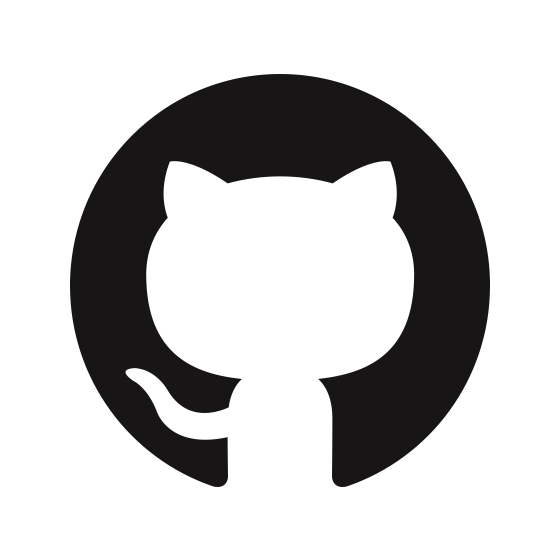
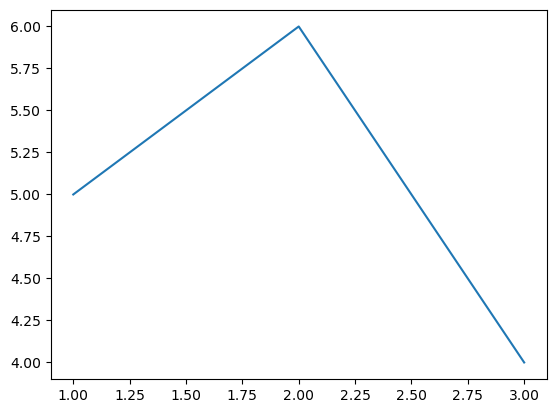

In [6]:
doc = pyd.Doc()

docpart = pyd.constr.markdown(children='My Markdown text')
doc.add(docpart)
docpart = pyd.constr.text(children='My plain text')
doc.add(docpart)
docpart = pyd.constr.verbatim(children='My preformatted text')
doc.add(docpart)
docpart = pyd.constr.image(imageblob='', caption='Empty image', children='', width=0.8)
doc.add(docpart)
docpart = pyd.constr.image_from_link(url='https://github.githubassets.com/assets/GitHub-Mark-ea2971cee799.png', caption='Github image', children='', width=0.8)
doc.add(docpart)
docpart = pyd.constr.image_from_file(path=r'C:\Users\tglaubach\repos\pydocmaker\example_templates\fancy_template.assets\fancy_logo.png', children='Some fancy logo', caption='', width=0.8)
doc.add(docpart)
fig = plt.figure()
plt.plot([1, 2, 3], [5, 6, 4])
docpart = pyd.constr.image_from_fig(caption='Pyplot figure', width=0.8, fig=fig)
doc.add(docpart)
docpart = pyd.constr.image_from_obj(np.atleast_2d(np.array(np.arange(255).tolist() * 255, dtype="uint8")), caption = '', width=0.8)
doc.add(docpart)

plt.close()
doc.show()